In [75]:
# Import necessary libraries for data analysis and machine learning
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import kagglehub
import datetime as dt
import calendar


# Import tools for data preprocessing
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder, RobustScaler
from sklearn.metrics import accuracy_score, r2_score, confusion_matrix, mean_squared_error, classification_report, root_mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split, learning_curve

# Import classic machine learning models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression

# import TensorFlow models' tools
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam, RMSprop
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, GlobalMaxPooling1D, Bidirectional, Dense, Flatten,SimpleRNN, Dropout, BatchNormalization, LSTM, GRU, Input, Conv1D, MaxPooling1D, Bidirectional

# Import tools for time series modeling
from statsmodels.tsa.seasonal import seasonal_decompose


# Import libraries for natural language processing (NLP)
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer

# Download necessary resources for nltk
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

## Part 1: Loading the Dataframes

**Stock Data:**

* This project analyzes Shopify's stock prices (SHOP) from September 23, 2018 to September 23, 2022 (3 years).
* Shopify helps businesses create online stores.
* The stock price shows how confident investors are in Shopify and the overall e-commerce market.
---
**News Data:**

* The news data comes from Kaggle's 'News Category Dataset'.
* It has around 210,000 headlines from the HuffPost news website between 2012 and 2022.
* About 10,000 of these headlines are from between May 2018 and 2022.
* We will use the 'category', 'headline', and 'date' of each news article for our analysis.

In [76]:
# Define the start and end dates for the data collection period
start_time = '2018-09-23'
end_time = '2022-09-23'

# Download Shopify stock data using yfinance for the specified period
stock_data = yf.download('SHOP', start = start_time, end = end_time)
# Simplify column names by removing multi-level indexing (tuples)
stock_data.columns = [col[0] for col in stock_data.columns]

# Download the news category dataset from Kaggle using kagglehub
path = kagglehub.dataset_download("rmisra/news-category-dataset")
# Define data types for the relevant columns in the news dataset
columns_types = {'headline': 'object', 'category': 'category', 'date':'datetime'}
# Read the JSON file into a pandas dataframe, selecting only relevant columns and specifying data types
news_data = pd.read_json(path + '/News_Category_Dataset_v3.json', dtype = columns_types,  lines=True, convert_dates=True, )[['headline', 'category', 'date']]

# Filter the news data to include only entries within the specified time period
mask = (news_data['date'] >= start_time) & (news_data['date'] <= end_time)
news_data = news_data[mask]

# Display information about the stock_data dataframe (data types, etc.)
stock_data.info()
# Print a blank line for better readability
print()
# Display information about the news_data dataframe
news_data.info()

[*********************100%***********************]  1 of 1 completed


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1007 entries, 2018-09-24 to 2022-09-22
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   1007 non-null   float64
 1   High    1007 non-null   float64
 2   Low     1007 non-null   float64
 3   Open    1007 non-null   float64
 4   Volume  1007 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 47.2 KB

<class 'pandas.core.frame.DataFrame'>
Index: 8107 entries, 0 to 8106
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   headline  8107 non-null   object        
 1   category  8107 non-null   category      
 2   date      8107 non-null   datetime64[ns]
dtypes: category(1), datetime64[ns](1), object(1)
memory usage: 199.3+ KB


In [77]:
# Display the first 5 rows of the stock_data & news_data dataframe
print(stock_data.head(5), end = '\n\n\n')
print(news_data.head(5))

                Close       High     Low       Open    Volume
Date                                                         
2018-09-24  16.218000  16.533001  15.740  15.956000   8926000
2018-09-25  16.111000  16.514000  15.900  16.337000  15798000
2018-09-26  16.200001  16.480000  15.988  16.252001   8605000
2018-09-27  16.445000  16.471001  16.202  16.226000   6043000
2018-09-28  16.445999  16.778999  16.306  16.419001   7894000


                                            headline   category       date
0  Over 4 Million Americans Roll Up Sleeves For O...  U.S. NEWS 2022-09-23
1  American Airlines Flyer Charged, Banned For Li...  U.S. NEWS 2022-09-23
2  23 Of The Funniest Tweets About Cats And Dogs ...     COMEDY 2022-09-23
3  The Funniest Tweets From Parents This Week (Se...  PARENTING 2022-09-23
4  Woman Who Called Cops On Black Bird-Watcher Lo...  U.S. NEWS 2022-09-22


## Part 2: EDA

### Stock Data

In [78]:
# Generate descriptive statistics for the stock data (mean, std, min, max, etc.)
stock_data.describe()

,Close,High,Low,Open,Volume
count,1007.000000,1007.000000,1007.000000,1007.000000,1.007000e+03
mean,71.609979,73.303438,69.824745,71.660892,2.174099e+07
std,46.384810,47.301162,45.475659,46.499072,1.402607e+07
min,11.910000,12.287000,11.764000,11.895000,4.713000e+06
25%,31.906500,32.759501,31.146600,31.839000,1.232400e+07
50%,54.437000,58.054001,53.407001,55.256001,1.785800e+07
75%,110.759499,114.450001,108.200001,111.134499,2.778400e+07
max,169.059998,176.291794,168.509506,171.800003,1.136080e+08


**Shopify Stock Data Observations (2018-09-23 to 2022-09-23)**

**DETAILS**
* **Average Price:** Around 71.61.
* **Volatility:** High, with a standard deviation of ~46.38.
* **Trading Volume:** Average of ~21.7 million shares, but with significant daily variability.
* **Price Range:** 11.91 to high as 169.06.
---
**INSIGHTS**
* Shopify stock is volatile, so be prepared for price swings.
* Trading volume varies daily.

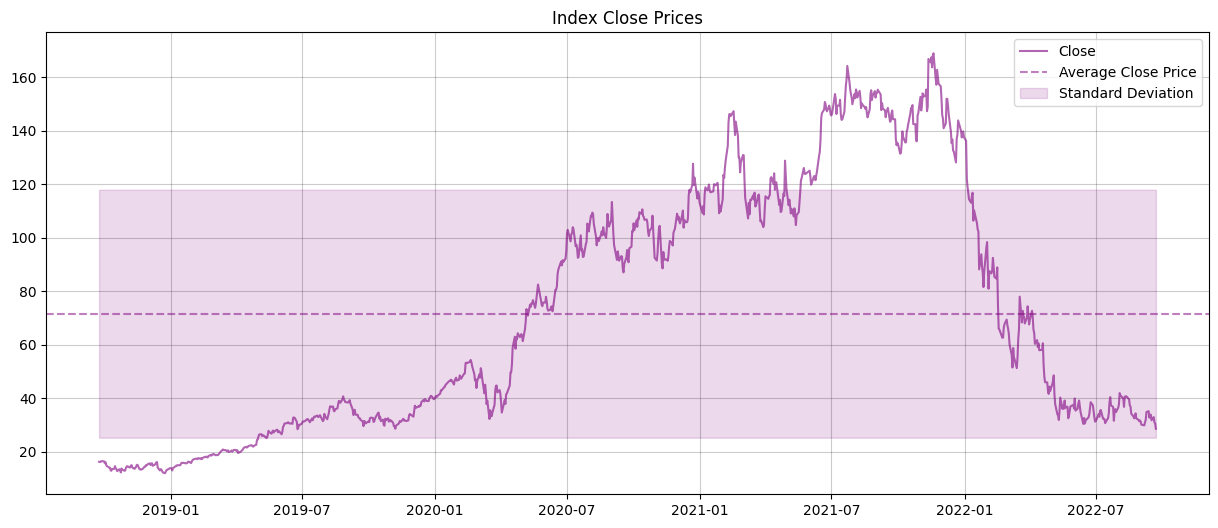

In [79]:
plt.figure(figsize = (15, 6))  # Create a figure with a specific size, for visually purposes.

# Plot the daily close prices, color purple, label 'Close'
plt.plot(stock_data['Close'], c = 'purple', label = 'Close', alpha = 0.6)
# Add a dashed horizontal line representing the average close price
plt.axhline(stock_data['Close'].mean(), ls = 'dashed', alpha = 0.5, color = 'purple', label = 'Average Close Price')
# Fill the area between one standard deviation above and below the average close price in near-transparent purple
plt.fill_between(stock_data.index, stock_data['Close'].mean() + stock_data['Close'].std(), stock_data['Close'].mean() - stock_data['Close'].std(), color = 'purple', alpha = 0.15,label = 'Standard Deviation')

plt.title('Index Close Prices') # Set the title of the plot
plt.legend() # Display the legend to show what the line represents
plt.grid(color = 'black', alpha = 0.2)  # Add a grid for better readability
plt.savefig('Close Prices.png') # Save the plot as an image file
plt.show() # Show the plot

* This chart shows the Shopify stock price each day.
* The dashed purple line is the average price. The light purple area shows the std up and down movement of the price.
* The price goes up and down a lot, which means it's risky.
* The price went up quickly from January 2020 to January 2021. This is probably because of COVID-19. More people shopped online and more businesses started selling online. This helped Shopify.
* Also, by the end of 2021, it seems like the stock price decreased, correcting itself after the big increase.

<Figure size 1500x1000 with 0 Axes>

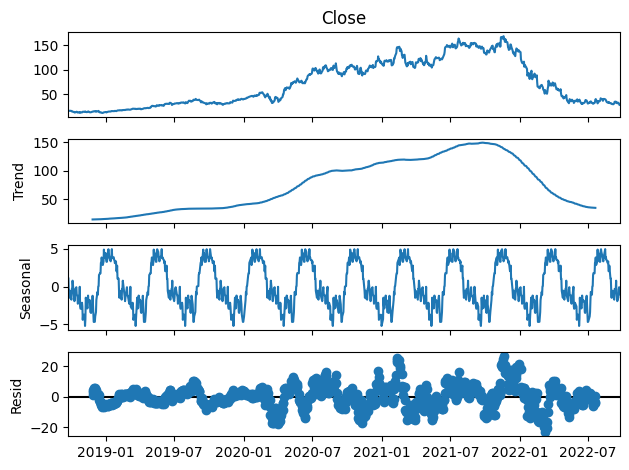

In [80]:
# Perform seasonal decomposition on the 'Close' price data using an additive model and a period of 60 days (approximately 2 months)
result = seasonal_decompose(stock_data['Close'], period= 90, model = 'add')

plt.figure(figsize = (15,10))
# Plot the decomposed components (trend, seasonal, noise)
result.plot()
plt.savefig('Seasonal Decomposition.png')
plt.show()

* This plot visualizes the trend, seasonality, and noise of the stock's closing prices over time.
* The trend line indicates a general upward movement in prices, although there are some deviations and errors.
* The trend also reveals a period of significant increase followed by a sharp decrease, suggesting a potential market correction or shift.

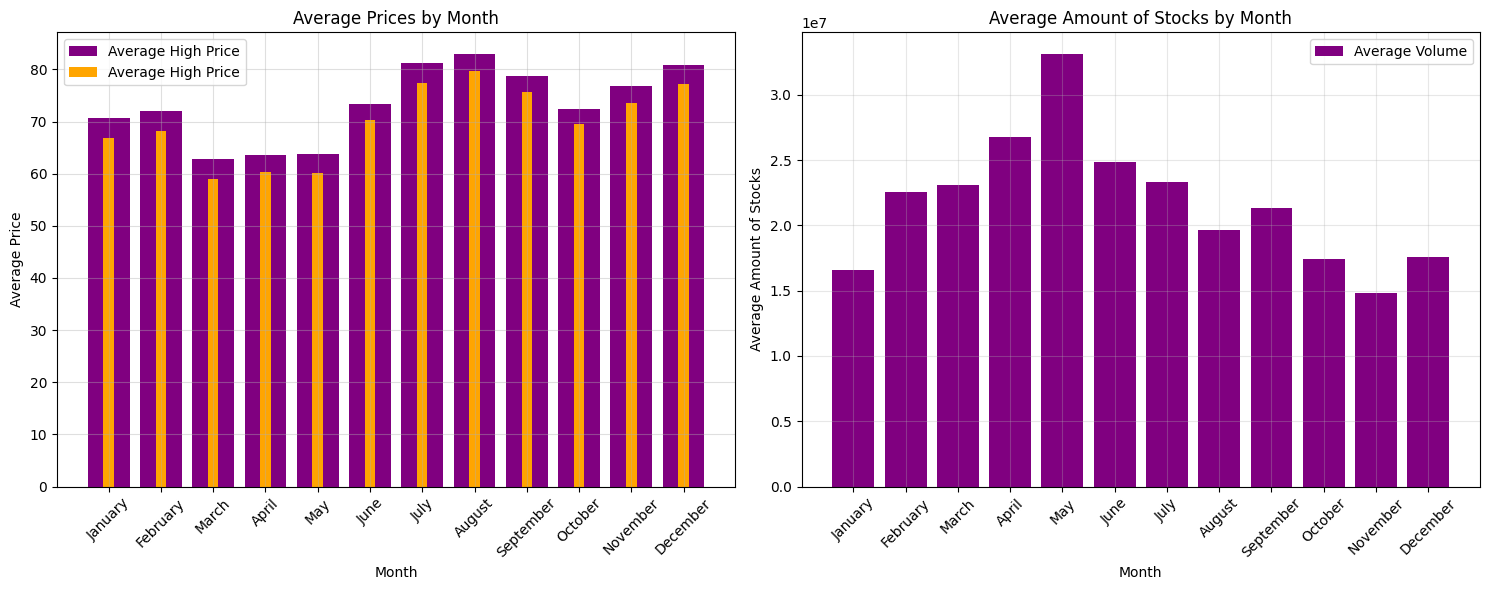

In [81]:
# Grouping the stock prices by month to calculate the average price for each month.
stock_by_month = stock_data.groupby(stock_data.index.month).mean()

# Create a figure with two subplots (1 row, 2 columns)
fig, ax = plt.subplots(1, 2, figsize = (15, 6))

# Plot the average High and Low prices in the first subplot
ax[0].bar(stock_by_month.index, stock_by_month['High'], color = 'purple', width= 0.8, label = 'Average High Price')
ax[0].bar(stock_by_month.index, stock_by_month['Low'], color = 'orange', width= 0.2, label = 'Average High Price')
ax[0].set_xlabel('Month')
ax[0].set_ylabel('Average Price')
ax[0].set_title('Average Prices by Month')
ax[0].grid(True, alpha=0.4)
ax[0].set_xticks(stock_by_month.index)
ax[0].set_xticklabels([calendar.month_name[m] for m in stock_by_month.index], rotation=45)
ax[0].legend()

# Plot the average Volume in the second subplot
ax[1].bar(stock_by_month.index, stock_by_month['Volume'], color = 'purple', label = 'Average Volume')
ax[1].set_xlabel('Month')
ax[1].set_ylabel('Average Amount of Stocks')
ax[1].set_title('Average Amount of Stocks by Month')
ax[1].grid(True, alpha=0.3)
ax[1].set_xticks(stock_by_month.index)
ax[1].set_xticklabels([calendar.month_name[m] for m in stock_by_month.index], rotation=45)
ax[1].legend()


plt.tight_layout()
plt.savefig('Average Prices and Volume by Month.png')
plt.show()

**This plot visualizes the stock's prices and volume over the time period grouped by the months. (purple - High/Volume, orange - Low)**

* It seems like the prices are lowest on March-May period, and the prices are the highest on the end of the year.

* The highest average price was around July-September, likely due to the increased demand for stocks in 2020-2021.

* The lowest price was in March-May possibly due to the correction after 2021, and because most of the peaks were around the end of the year.

* It seems like the highest average volume is around April-June, which may be related to COVID-19, as a lot of people purchased/sold the stock during that period (due to market enthusiasm or correction).

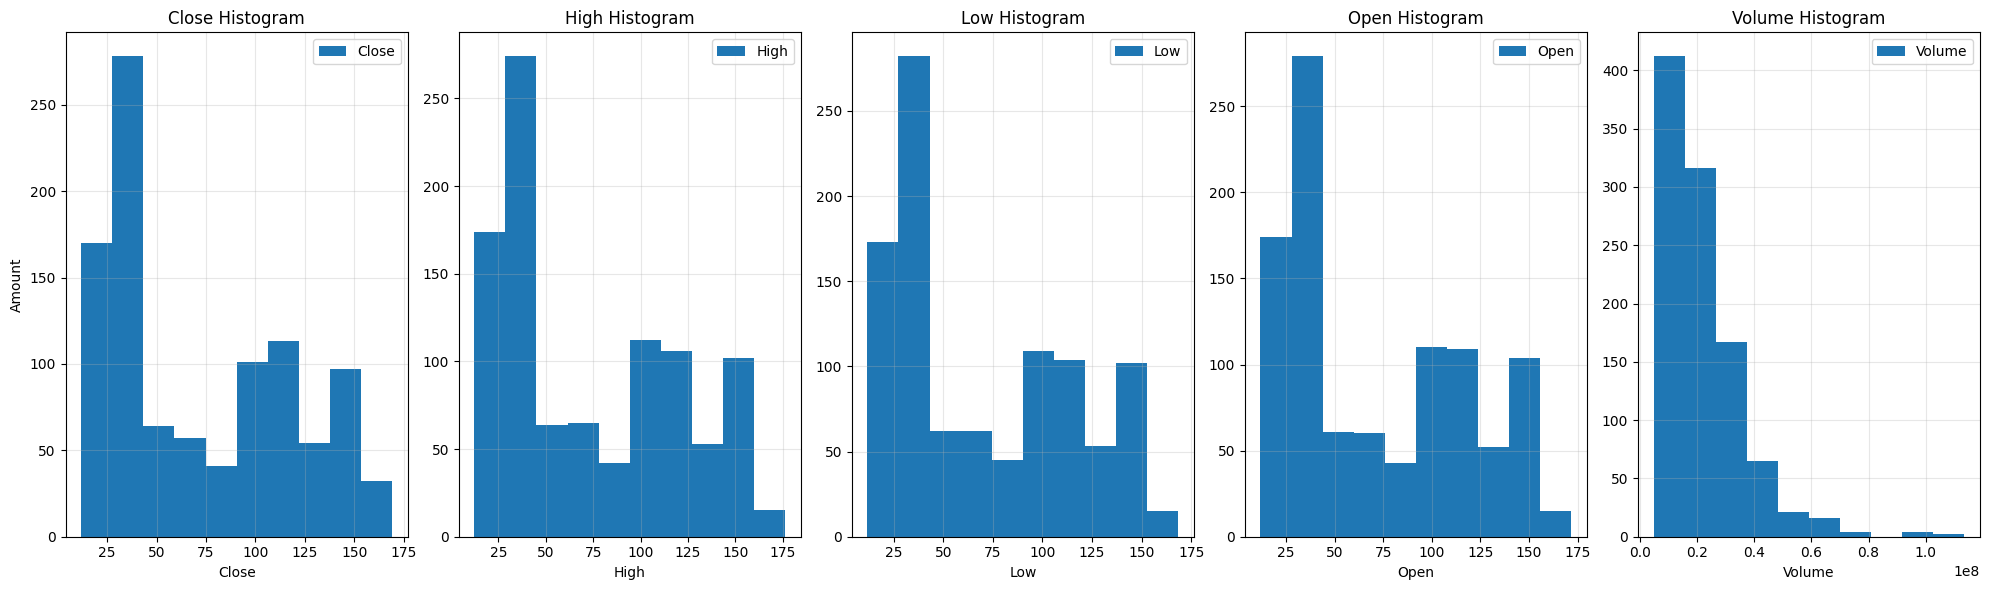

In [82]:
# Create a figure with subplots for each column in the stock data
fig, ax = plt.subplots(1, len(stock_data.columns), figsize = (20,6))

# Iterate through each column and create a histogram
for i, col in enumerate(stock_data.columns):
  ax[i].hist(stock_data[col], label = col, bins = 10)
  ax[i].grid(True, alpha=0.3)
  ax[0].set_ylabel('Amount')
  ax[i].set_xlabel(col)
  ax[i].set_title(f'{col} Histogram')
  ax[i].legend()

plt.tight_layout()
plt.savefig('Stock Details Histogram.png')
plt.show()

**This plot visualize the stock's details histogram, each histogram is showing how much of each value is in this dataset.**


* The histograms for Open, High, Low, and Close prices share a similar shape. Most prices are below 50, with some values reaching beyond 150.

* The histogram shows that the prices range are very violated, and vary in very big range. This is not normal distibution.


* The Volume histogram indicates that most trading volumes are below 2e7 (20 million).

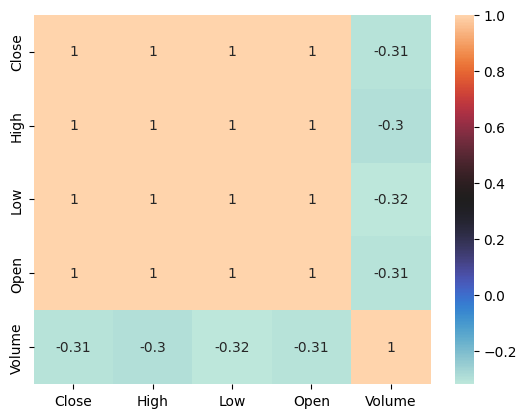

In [83]:
# Scale the data using MinMaxScaler since it's not normally distributed.
min_max_scaler = MinMaxScaler()
stock_data_scaled = min_max_scaler.fit_transform(stock_data)

# Visualize correlations between columns using a heatmap.
sns.heatmap(pd.DataFrame(stock_data_scaled).corr(), annot = True, cmap = 'icefire', yticklabels =stock_data.columns, xticklabels=stock_data.columns)
plt.savefig('Stock Details Correlation.png')
plt.show()

**This plot visualizes the correlations between the stock's details.**

* It seems like the Open, Close, High, and Low prices are almost perfectly correlated.

* However, the Volume doesn't show any correlation to the prices. But Avital (my mentor 😀) told me it's worth looking.

### News Data

In [84]:
# Generate descriptive statistics for the stock data (mean, std, min, max, etc.)
news_data.describe()

,date
count,8107
mean,2020-09-18 09:32:50.297273856
min,2018-09-23 00:00:00
25%,2019-09-26 00:00:00
50%,2020-09-22 00:00:00
75%,2021-09-10 00:00:00
max,2022-09-23 00:00:00


* Not so useful...

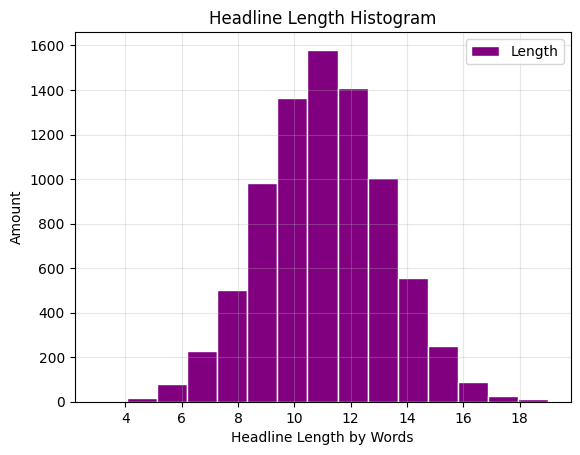

In [85]:
# Visualize the distribution of headline lengths (by words) using a histogram.
plt.hist(news_data['headline'].apply(lambda x: len(x.split())), color = 'purple', edgecolor = 'w', label = 'Length', bins = 15)
plt.legend()
plt.xlabel('Headline Length by Words')
plt.ylabel('Amount')
plt.title('Headline Length Histogram')
plt.grid(True, alpha=0.3)
plt.savefig('Headline Length Histogram.png')
plt.show()

**This plot visualizes the distribution of headline lengths (by words) using a histogram.**

* It appears that the headline lengths are roughly normally distributed, most of the headlines are containing around 10-12 words

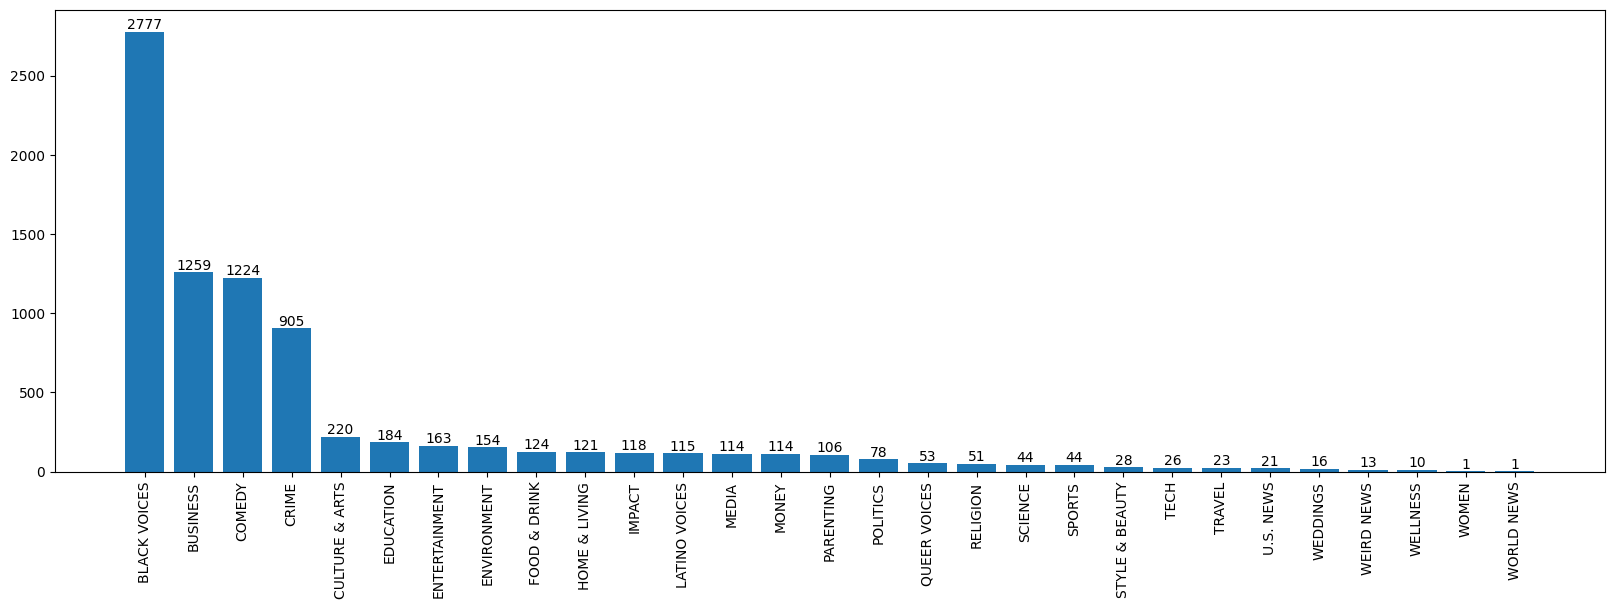

In [86]:
# Group the news data by category.
# observe is set to True to avoid showing the categories that are not in the specific period of time
news_by_cat = news_data.groupby(news_data['category'], observed = True)

plt.figure(figsize = (20,6))

# Visualize the number of headlines per category using a bar plot.
bars = plt.bar(news_by_cat.groups.keys(), news_by_cat['headline'].count().sort_values(ascending = False))

# Add text labels above each bar to show the count of headlines.
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height}',
             ha='center', va='bottom') # placing text over each bar, in the middle of the bar's top, with center horizontal alignment and bottom vertical alignment

#rotate the labels, so there will be no overlapping
plt.xticks(rotation=90)
plt.savefig('Headline Categories.png')
plt.show()


**This plot visualizes the number of headlines per news category.**

* The top 5 categories are Arts, Arts, Arts & Culture, Black Voices, Business, and College.

* This suggests that the 'category' feature might not be very helpful for predicting stock prices, as most headlines are unrelated to finance or e-commerce. (My opinion)

* NOTE: However, it could be interesting to explore if these categories can reveal trends in e-commerce or identify popular products.


In [87]:
# Create a 'Shift' column to calculate the percentage change in daily closing prices.
stock_data["Shift"] = stock_data["Close"].pct_change()

# Create a 'Label' column to categorize price movements:
# 1 for price increase, -1 for price decrease, 0 for no change.
stock_data["Label"] = [-1 if shift < 0 else 1 if shift > 0 else 0 for shift in stock_data["Shift"]]

# Remove the 'Shift' column as it's no longer needed.
stock_data.drop(columns = ['Shift'], inplace = True) # Not neccessary anymoreA

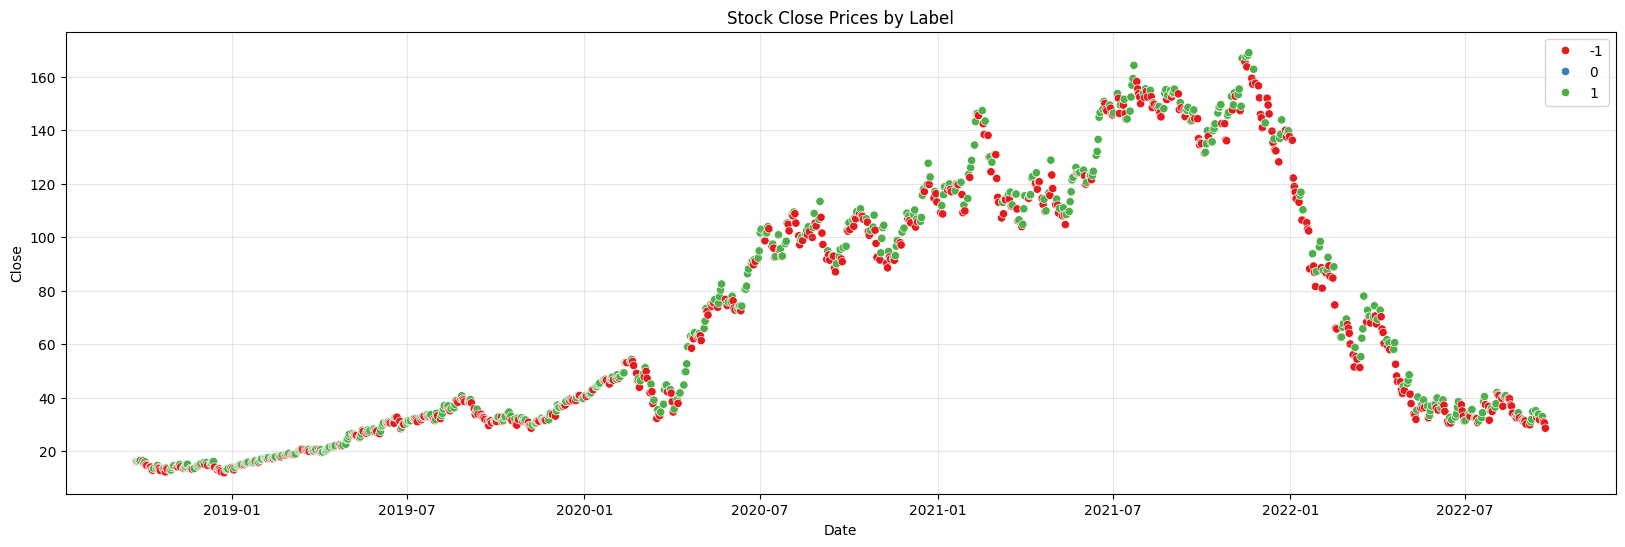

In [88]:
plt.figure(figsize = (20, 6))

# Plot the daily close prices, color purple, label 'Close'
# using scatterplot, with hue based on the 'Label' column.
sns.scatterplot(data = stock_data, x = stock_data.index, y = 'Close', hue = 'Label', palette= 'Set1', )
plt.title('Stock Close Prices by Label')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('Stock Close Prices by Label.png')
plt.show()

**This scatter plot visualizes the daily closing prices of Shopify stock over time, color-coded by the 'Label' column, which indicates whether the price increased (1), decreased (-1), or stayed the same (0).**

* Based on the plot, I've decided not to engineer features related to the date for predicting the labels, as there aren't enough visible clusters to aid the models.

* Also, I've decided to omit data points with no change in price (Label = 0). They are nearly invisible on the graph, and I will demonstrate in the next line that they are negligible compared to the other labels.



In [89]:
# Display the frequency of each label (price movement category) in the dataset.
stock_data['Label'].value_counts()

,count
Label,
1,531
-1,475
0,1


In [90]:
# Remove rows where the price did not change (Label = 0).
# Because there's only 1 of these.
stock_data = stock_data[stock_data["Label"] != 0]

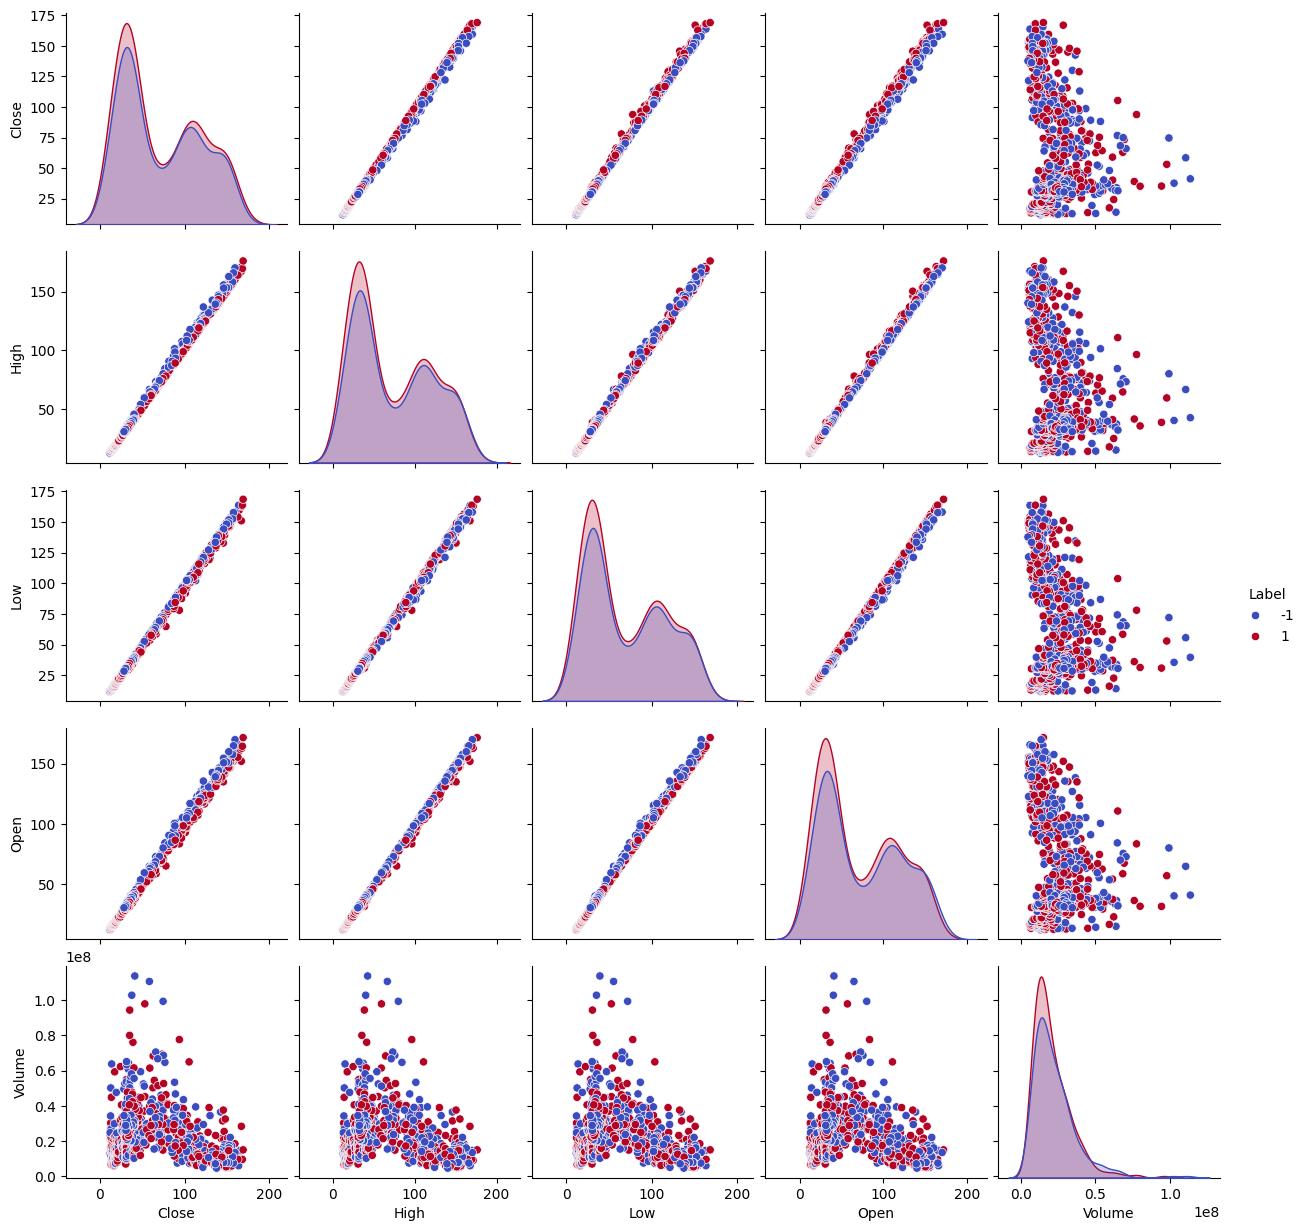

In [133]:
# Visualize relationships between features and labels using a pair plot.
sns.pairplot(stock_data, hue = 'Label', palette = 'coolwarm')
plt.savefig('Stock Details Pairplot.png')
plt.show()

**This pair plot visualizes the relationships between different features in the stock_data DataFrame and how they might influence the separation of labels (price movements).**

* Based on this plot, I have decided not to include the volume in my dataset for the classic models, since there's no clear separation of labels based on volume.

* It seems like the separation of the clusters could be linear, with the Close/High pair plot indicating the strongest relationship for separating the labels.

* Also, since I'm not using volume, I might consider not scaling the data, as I don't want to minimize my range of data and potentially affect the models' performance.

* Based on these observations, I will use the Logistic Regression, and SVM models.


## Part 3: Classic Models

### Preparing the data

In [92]:
# Create a copy of the stock_data DataFrame and remove the 'Volume' column.
new_stock_data = stock_data.copy()
new_stock_data = new_stock_data.drop(columns = ['Volume'])


# Prepare the data for modeling: Encode labels and separate features/target.
encoder = LabelEncoder()
X = new_stock_data.drop(columns = ['Label'])
y = encoder.fit_transform(new_stock_data['Label'])

# Split the data into train and test sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state = 42)
X_train, X_test = X_train.astype('float'), X_test.astype('float')

# Scale the data using MinMaxScaler (decided to scaler, because it did not matter).
scaler = MinMaxScaler(feature_range = (-1,1))
X_train, X_test = scaler.fit_transform(X_train), scaler.transform(X_test)


### Logistic Regression

In [134]:
# Creating the Logistic Regression model.
LR_model = LogisticRegression(solver='saga', penalty = 'l1' , max_iter = 5000, C = 100,  random_state = 42)

# Train the Logistic Regression model on the training data.
LR_model.fit(X_train, y_train)

# Make predictions on the training and testing data.
lr_y_val, lr_y_pred = LR_model.predict(X_train), LR_model.predict(X_test)

# Print the accuracy scores for the training and testing sets, along with the delta.
print(f'LR Regression accuracy for train: {round(accuracy_score(lr_y_val, y_train), 3) }, for test: {round(accuracy_score(lr_y_pred, y_test), 3)}, delta: {round((accuracy_score(lr_y_val, y_train) - accuracy_score(lr_y_pred, y_test))*100 , 3)}%')


LR Regression accuracy for train: 0.856, for test: 0.861, delta: -0.566%


**INSIGHTS**
* The Linear Regression model achieves an accuracy of approximately 86% on the training set and ~87% on the test set.
* The difference between the scores is ~0.44%.
This difference might lead to the conclusion that there is not enough data to train the model.

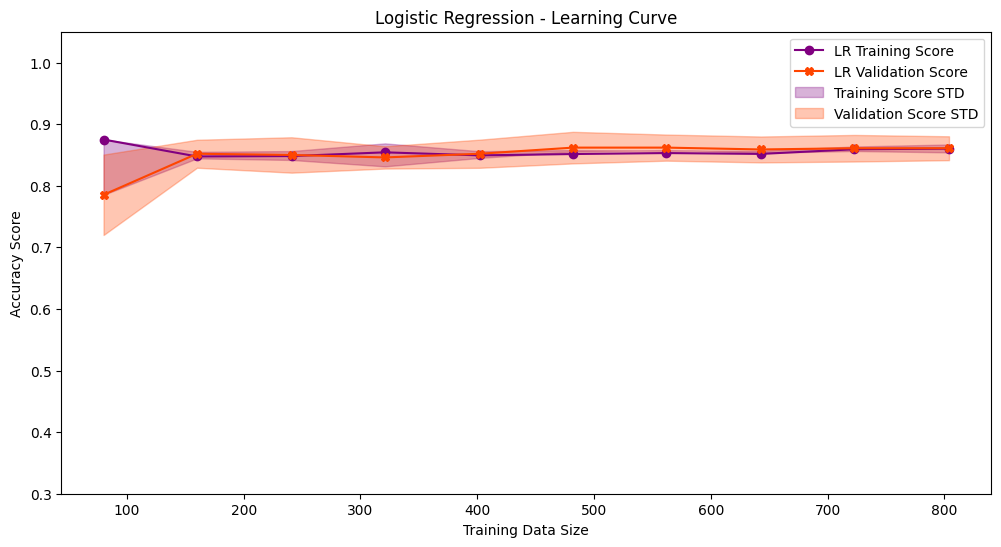

In [138]:
# Generate the learning curve data.
train_sizes, train_scores, val_scores = learning_curve(
    estimator = LR_model,
    X = X,
    y = y,
    train_sizes = np.linspace(0.1, 1.0, 10),
    cv = 5,
    scoring =  'accuracy',
    random_state = 42
)

# Calculate the mean and standard deviation of training and validation scores.
lr_train_mean = np.mean(train_scores, axis=1)
lr_train_std = np.std(train_scores, axis=1)
lr_val_mean = np.mean(val_scores, axis=1)
lr_val_std = np.std(val_scores, axis=1)


plt.figure(figsize=(12, 6))
# Create the learning curve plot.
plt.plot(train_sizes, lr_train_mean, label='LR Training Score', color='purple', marker='o')
plt.plot(train_sizes, lr_val_mean, label='LR Validation Score', color='orangered', marker='X')
# Fill the area around the mean scores to represent standard deviation.
plt.fill_between(train_sizes, lr_val_mean - lr_train_std, lr_train_mean + lr_train_std, color='purple', alpha=0.3, label = 'Training Score STD')
plt.fill_between(train_sizes, lr_val_mean - lr_val_std, lr_val_mean + lr_val_std, color='orangered', alpha=0.3, label = 'Validation Score STD')

plt.title('Logistic Regression - Learning Curve')
plt.xlabel('Training Data Size')
plt.ylabel('Accuracy Score')
plt.ylim(0.3, 1.05)
plt.legend()
plt.savefig('Logistic Regression - Learning Curve.png')
plt.show()

**This plot visualzing the learing curve of the Linear Model model.**
* The model initially achieves high accuracy on the training set, which gradually stabilizes and converges with the validation accuracy as the training data size grows.

* The decreasing standard deviation of the training scores indicates the model's learning improves with more data. However, the relatively constant validation standard deviation suggests potential overfitting, although it remains within an acceptable range (maximum 6%).


* Interestingly, the final validation accuracy slightly surpasses the test accuracy. This might indicate that the available data is insufficient for optimal model training and generalization.

### SMV Model

In [95]:
# Initialize the Support Vector Machine (SVM) modeL.
SVM_model = SVC(kernel='rbf', C = 1e5, random_state = 42,)

# Train the SVM model on the training data.
SVM_model.fit(X_train, y_train)

# Make predictions on the training and testing data.
svm_y_val, svm_y_pred = SVM_model.predict(X_train), SVM_model.predict(X_test)

# Print the accuracy scores for the training and testing sets, along with the delta.
print(f'SVM accuracy for train: {round(accuracy_score(svm_y_val, y_train), 3) }, for test: {round(accuracy_score(svm_y_pred, y_test), 3)}, delta: {round((accuracy_score(svm_y_val, y_train) - accuracy_score(svm_y_pred, y_test))*100 , 3)}%')

SVM accuracy for train: 0.871, for test: 0.876, delta: -0.559%


**INSIGHTS**
* The SVM model achieves an accuracy of approximately 86% on the training set and ~86% on the test set.
* The difference between the scores is ~0.3%.
* The difference suggest there is no overfitting, since it so small.
* Also, I noticed that the higher the C parameter is, the better the accuracy score.
* This is legit since we observed in the pairplot before that the data is actually separated, so higher C means that the model will be more complex, so the seperation could match more accuratly, while not recieving overfitting.
* However, for computing matters, I will use C that is not exaggerated.


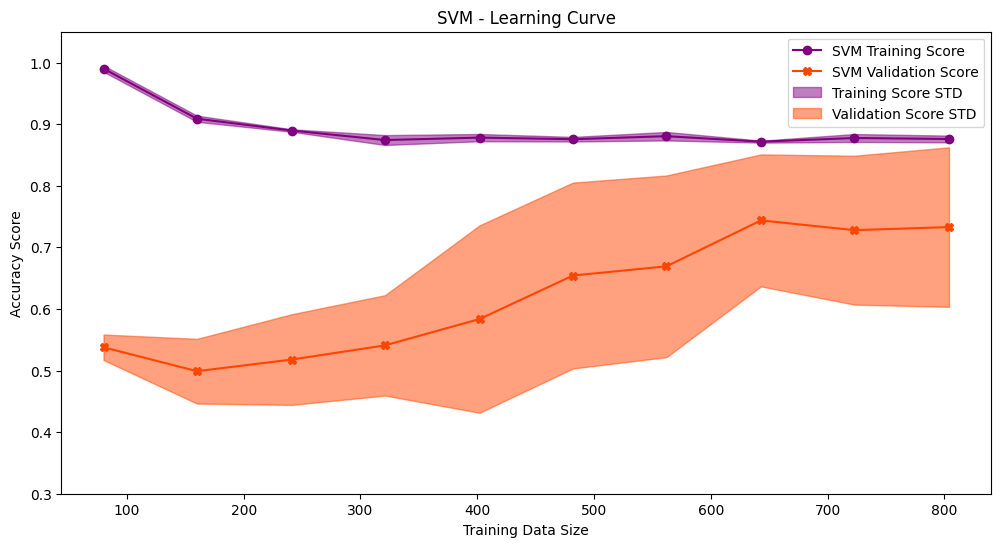

In [139]:
# Generate the learning curve data for the SVM model.
train_sizes, train_scores, val_scores = learning_curve(
    estimator = SVM_model,
    X = X,
    y = y,
    train_sizes = np.linspace(0.1, 1.0, 10),
    cv = 5,
    scoring =  'accuracy',
    random_state = 42
)

# Calculate the mean and standard deviation of training and validation scores.
SVM_train_mean = np.mean(train_scores, axis=1)
SVM_train_std = np.std(train_scores, axis=1)
SVM_val_mean = np.mean(val_scores, axis=1)
SVM_val_std = np.std(val_scores, axis=1)

# Create and display the learning curve plot for the SVM model.
plt.figure(figsize=(12, 6))
plt.plot(train_sizes, SVM_train_mean, label='SVM Training Score', color='purple', marker='o')
plt.plot(train_sizes, SVM_val_mean, label='SVM Validation Score', color='orangered', marker='X')

# Fill the area around the mean scores to represent standard deviation.
plt.fill_between(train_sizes, SVM_train_mean - SVM_train_std, SVM_train_mean + SVM_train_std, color='purple', alpha=0.5, label = 'Training Score STD')
plt.fill_between(train_sizes, SVM_val_mean - SVM_val_std, SVM_val_mean + SVM_val_std, color='orangered', alpha=0.5, label = 'Validation Score STD')
plt.title('SVM - Learning Curve')
plt.xlabel('Training Data Size')
plt.ylabel('Accuracy Score')
plt.ylim(0.3, 1.05)
plt.legend()
plt.show()

In [97]:
print('LOGISTOC')
# Print the maximum standard deviation of the validation scores (in percentage).
print('Maximum STD in the process:', round(max(lr_val_std * 100), 3))
# Print the average standard deviation of the validation scores (in percentage).
print('Average STD in the process:', round(np.mean(lr_val_std * 100), 3))
# Print the last standard deviation of validation scores (in percentage).
print('Last STD in the process:', round(list(lr_val_std * 100)[-1], 3))
print('_________________')
print('SVM')
# Print the maximum standard deviation of the validation scores (in percentage).
print('Maximum STD in the process:', round(max(SVM_val_std * 100), 3))
# Print the average standard deviation of the validation scores (in percentage).
print('Average STD in the process:', round(np.mean(SVM_val_std * 100),3))
# Print the last standard deviation of validation scores (in percentage).
print('Last STD in the process:', round(list(SVM_val_std * 100)[-1], 3))


LOGISTOC
Maximum STD in the process: 6.528
Average STD in the process: 2.665
Last STD in the process: 1.94
_________________
SVM
Maximum STD in the process: 15.209
Average STD in the process: 10.362
Last STD in the process: 12.947


In [98]:
# Show Cassification Report for Logistic Regression model.
print('Logistic Regression Classification Report')
print(classification_report(y_test, lr_y_pred))

# Show Cassification Report for SVM model.
print('SVM Classification Report')
print(classification_report(y_test, svm_y_pred))

Logistic Regression Classification Report
              precision    recall  f1-score   support

           0       0.90      0.79      0.84        95
           1       0.83      0.93      0.88       107

    accuracy                           0.86       202
   macro avg       0.87      0.86      0.86       202
weighted avg       0.87      0.86      0.86       202

SVM Classification Report
              precision    recall  f1-score   support

           0       0.88      0.85      0.87        95
           1       0.87      0.90      0.88       107

    accuracy                           0.88       202
   macro avg       0.88      0.87      0.88       202
weighted avg       0.88      0.88      0.88       202



* Based on these classification reports, the Logistic Regression and SVM models performed good.

* Logistic Regression achieved the highest overall accuracy (86%) and had a precision of 90% for predicting decreasing prices (class 0).


* The SVM model also performed well, with similar accuracy (86%) and precision (89% for class 0), but slightly lower recall for decreasing prices compared to Logistic Regression.

* Logistic Regression was better at avoiding false alarms for decreasing prices, but SVM was better at actually finding those decreases when they happened.



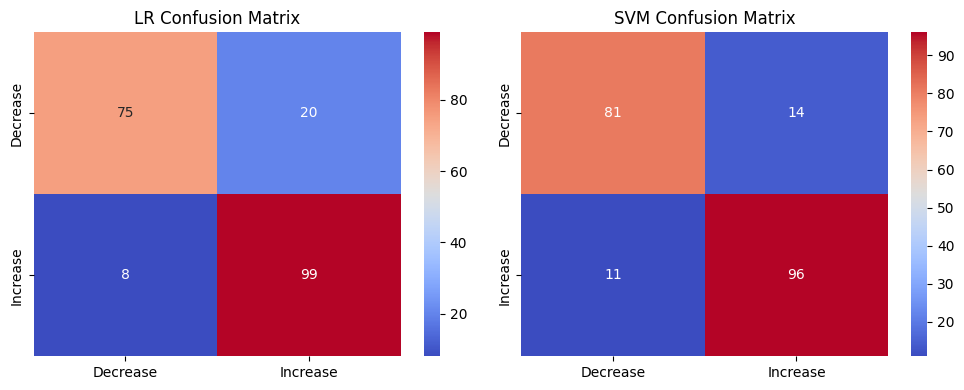

In [142]:
fig, ax = plt.subplots(1, 2, figsize = (10, 4))
sns.heatmap(confusion_matrix(y_test, lr_y_pred), ax = ax [0], annot = True, cmap = 'coolwarm', yticklabels = ['Decrease', 'Increase'], xticklabels=['Decrease', 'Increase'])
ax[0].set_title('LR Confusion Matrix')


sns.heatmap(confusion_matrix(y_test, svm_y_pred), ax = ax [1], annot = True, cmap = 'coolwarm', yticklabels = ['Decrease', 'Increase'], xticklabels=['Decrease', 'Increase'])
ax[1].set_title('SVM Confusion Matrix')


plt.tight_layout()
plt.show()

## Part 4: Time Series Model

In [100]:
def windowed_dataset(df, window_size, batch_size, shuffle_buffer = None):
    """
    Generates a windowed dataset for time series forecasting.

    Args:
      df: The time series dataframe.
      window_size: The size of the sliding window.
      batch_size: The batch size for training.
      shuffle_buffer: The buffer size for shuffling the data.

    Returns:
      A tf.data.Dataset object containing the windowed data.
    """
    # Create a dataset from the series
    dataset = tf.data.Dataset.from_tensor_slices(df.values)
    # Create windows of data
    dataset = dataset.window(window_size + 1, shift = 1, drop_remainder=True)
    # Flatten the windows
    dataset = dataset.flat_map(lambda window: window.batch(window_size + 1))
    # Separate features and target
    dataset = dataset.map(lambda window: (window[:-1], window[-1, 0]))
    if shuffle_buffer:
      dataset = dataset.shuffle(shuffle_buffer).batch(batch_size).prefetch(1)
    else:
      dataset = dataset.batch(batch_size).prefetch(1)
    return dataset

In [101]:
# Set scalers
scaler = MinMaxScaler(feature_range=(-1, 1))
price_scaler = MinMaxScaler(feature_range=(-1, 1))

# Split the data into training and validation sets
split_time = int(len(stock_data)*0.8)

# Set training and validation sets for the time series models.
X_fit, X_valid = stock_data[:split_time].iloc[:, :4], stock_data[split_time:].iloc[:, :4]

# Scale the Close price column.
X_fit['Close'], X_valid['Close'] = price_scaler.fit_transform(X_fit[['Close']]), price_scaler.transform(X_valid[['Close']])

# Scale the data for the
for col1, col2 in zip(X_fit.columns.drop('Close'), X_valid.columns.drop('Close')):
    X_fit[col1], X_valid[col2] = scaler.fit_transform(X_fit[[col1]]), scaler.transform(X_valid[[col2]])


In [102]:

# Set the window size and batch size for the dataset
WINDOW_SIZE = 60
BATCH_SIZE = 6
SHUFFLE_BUFFER = 1000

# Create the training and validation datasets using the windowed_dataset function
train_dataset = windowed_dataset(X_fit, WINDOW_SIZE, BATCH_SIZE,  SHUFFLE_BUFFER)
valid_dataset = windowed_dataset(X_valid, WINDOW_SIZE, BATCH_SIZE, SHUFFLE_BUFFER)


In [103]:

# Define the time series model using Keras Sequential API
ts_model = Sequential([
    Input(shape = (WINDOW_SIZE, X_fit.shape[1])),
    LSTM(128, return_sequences= True),
    LSTM(128,),
    Dense(1, activation=None)
])


# Compile the model
ts_model.compile(loss="mse",
                 optimizer = tf.keras.optimizers.Adam(learning_rate = 0.001),
                 metrics = ['mae'])

# Define callbacks for early stopping and learning rate reduction
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_mae', patience = 7, restore_best_weights = True,),
    tf.keras.callbacks.ReduceLROnPlateau(monitor = 'val_mae', patience = 4, factor = 0.3333),
    ]

# Train the model
history = ts_model.fit(
    train_dataset,
    validation_data = valid_dataset,
    epochs = 40,
    batch_size = 64,
    callbacks = callbacks,
    verbose = 2,
)


Epoch 1/40


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:151: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


124/124 - 16s - 131ms/step - loss: 0.0152 - mae: 0.0809 - val_loss: 0.0076 - val_mae: 0.0703 - learning_rate: 1.0000e-03
Epoch 2/40
124/124 - 18s - 147ms/step - loss: 0.0053 - mae: 0.0544 - val_loss: 0.0044 - val_mae: 0.0495 - learning_rate: 1.0000e-03
Epoch 3/40
124/124 - 10s - 82ms/step - loss: 0.0044 - mae: 0.0494 - val_loss: 0.0037 - val_mae: 0.0448 - learning_rate: 1.0000e-03
Epoch 4/40
124/124 - 10s - 77ms/step - loss: 0.0037 - mae: 0.0454 - val_loss: 0.0039 - val_mae: 0.0475 - learning_rate: 1.0000e-03
Epoch 5/40
124/124 - 9s - 75ms/step - loss: 0.0031 - mae: 0.0412 - val_loss: 0.0037 - val_mae: 0.0463 - learning_rate: 1.0000e-03
Epoch 6/40
124/124 - 11s - 86ms/step - loss: 0.0033 - mae: 0.0435 - val_loss: 0.0064 - val_mae: 0.0689 - learning_rate: 1.0000e-03
Epoch 7/40
124/124 - 10s - 77ms/step - loss: 0.0027 - mae: 0.0379 - val_loss: 0.0033 - val_mae: 0.0434 - learning_rate: 1.0000e-03
Epoch 8/40
124/124 - 10s - 77ms/step - loss: 0.0025 - mae: 0.0370 - val_loss: 0.0030 - val_ma

In [150]:
ts_model_scores = ts_model.evaluate(valid_dataset, return_dict = True)
# Print the best MSE and the epoch it was achieved
for key, value in ts_model_scores.items():
    print(key, ':', round(value, 4))

24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0014 - mae: 0.0296
loss : 0.0014
mae : 0.0285


In [105]:
valid_dataset_for_pred = windowed_dataset(X_valid, WINDOW_SIZE, BATCH_SIZE)
ts_pred = ts_model.predict(valid_dataset_for_pred)

24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step


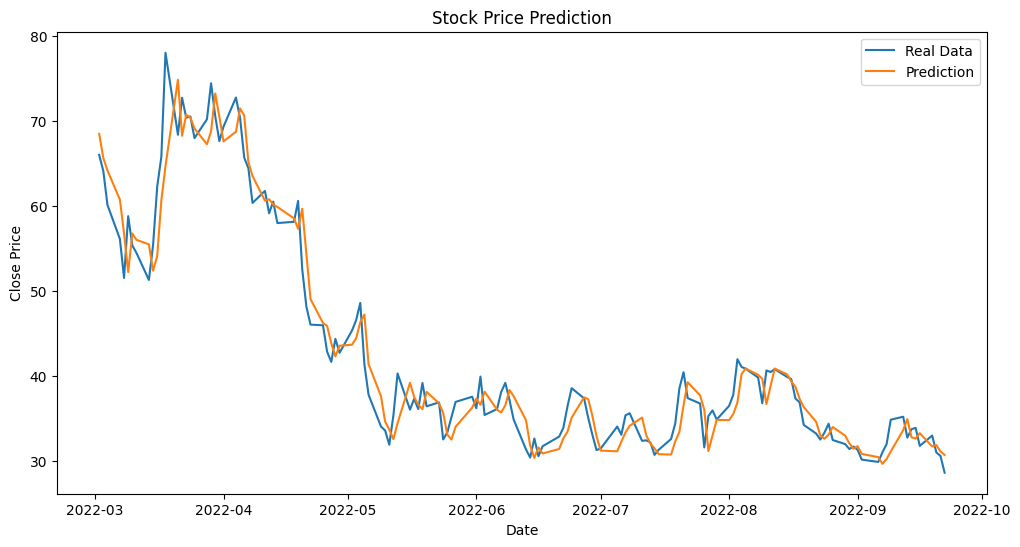

In [144]:

plt.figure(figsize=(12,6))

# Plot the actual stock prices (from the split time onwards)
plt.plot(stock_data.index[split_time + WINDOW_SIZE:], stock_data['Close'][split_time + WINDOW_SIZE:], label = 'Real Data',)

plt.plot(stock_data.index[split_time + WINDOW_SIZE:], price_scaler.inverse_transform(ts_pred), label = 'Prediction')

plt.title('Stock Price Prediction')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()

* The Time Series model have MAE equals to \$7, indicatind there is error of \$7 in its' prediction.

* Also, Based on the model, it might guess the label of Increased/Decreased, but the concept of time sequences make the date important for the prediction, while in the classic models we ommited that part. also,

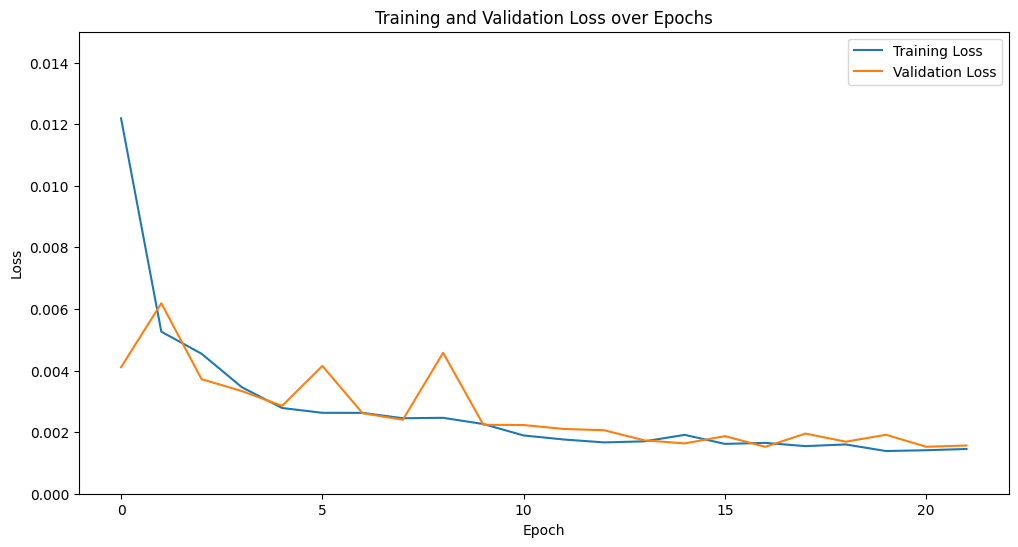

In [145]:
plt.figure(figsize=(12, 6))

# Plot the training loss over epochs
plt.plot(history.history['loss'], label='Training Loss')

# Plot the validation loss over epochs
plt.plot(history.history['val_loss'], label='Validation Loss')

# Set the title of the plot
plt.title('Training and Validation Loss over Epochs')
plt.xlabel('Epoch')
plt.ylim(0, 0.015)
plt.ylabel('Loss')
plt.legend()
plt.show()

* Time series models are designed for forecasting, not just predicting the previous day's movement.

* Ideally, we'd retrain the model with all data for best performance.

* My hypothesis: the time series model will be more accurate because it uses the data's sequential nature and future information.

* I did not compare the models, since there is no simple way to compare the labels, since on is forecating the future price, and the classic models predicting the previous prices.

In [109]:
print("R2 Score for the model:", r2_score(stock_data['Close'][split_time + WINDOW_SIZE:], price_scaler.inverse_transform(ts_pred)))

R2 Score for the model: 0.948023288587305


## Part 5: NLP & Sentiment

In [167]:
# Import the regular expression module for text processing
import re

# Create a copy of the news data
new_news_data = news_data.copy()

# Prepare for sentiment analysis using Natural Language Processing (NLP)
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
  """
  Cleans and preprocesses text data for NLP tasks.

  Args:
      text: The input text string.

  Returns:
      The cleaned and preprocessed text string.
  """
  # remove '.' characters and replace them with spaces
  text = re.sub("\.", '', text)
  # Tokenize the text and convert to lowercase
  words = word_tokenize(str(text).lower())
  # Lemmatize words, keep only alphanumeric words, and remove stop words
  words = [lemmatizer.lemmatize(word) for word in words if word.isalnum() and word not in stop_words]
  # Join the processed words back into a string
  return " ".join(words)

# Apply the clean_text function to the headlines and categories
clean_headlines = (new_news_data["headline"] + " " + new_news_data["category"].astype('object')).apply(clean_text)

In [168]:
#   המרת טקסט ל-Tokenizer
MOST_COMMON = 6000
tokenizer = Tokenizer(oov_token ='<OOV>', num_words = MOST_COMMON)
tokenizer.fit_on_texts(clean_headlines)
sequences = tokenizer.texts_to_sequences(clean_headlines)

X_nlp = pad_sequences(sequences, maxlen = max([len(seq) for seq in sequences]), padding='pre', truncating='pre')

print('Corpus length: ', len(list(tokenizer.word_index.keys())))
print('Max sentence length after cleaning:', max([len(seq) for seq in sequences]))
print('Top 30 common words:', )
for word in list(tokenizer.word_index.keys())[1:31]:
    print(word,)

new_news_data["sequence"] = X_nlp.tolist()

Corpus length:  10911
Max sentence length after cleaning: 16
Top 30 common words:
politics
news
u
entertainment
trump
world
say
new
biden
woman
coronavirus
donald
comedy
home
gop
sport
house
year
beauty
crime
get
medium
style
call
first
death
black
show
food
week


In [211]:
# Import the random module for reproducibility
import random
# Set the random seed for consistent results
random.seed(42)

# Define the NLP model using Keras Sequential.
nlp_model = Sequential([
    # Embedding layer to represent words as vectors
    Embedding(input_dim = len(tokenizer.word_index) + 1, output_dim = 8), # input_dim - אורך של הלקסיקון שלנו, output_dim - כמה "קונוטציות" יש למילה
    GRU(256),
    # Dense layer with LeakyReLU activation
    Dense(64,),
    Dense(1, ),
    tf.keras.layers.Lambda(lambda x: tf.keras.activations.sigmoid(x * 100 ))
]
)

# Compile the model
nlp_model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate = 1e-03),
    loss = "mse",
    metrics = ['mae']
)

# Make predictions on the news data sequences to create sentiments, and setting in the dataframe.
sentiment = nlp_model.predict(tf.convert_to_tensor(new_news_data['sequence'].to_list()))
new_news_data['sentiment'] = sentiment

254/254 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step


0.2737261652946472
0.7205066680908203
0.06821222603321075
0.51412266


<Axes: ylabel='Frequency'>

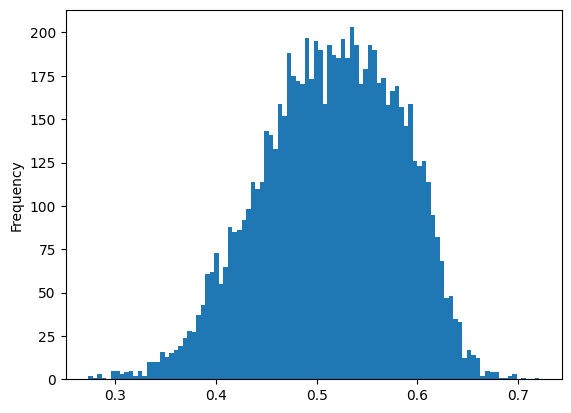

In [212]:
print(new_news_data['sentiment'].min())
print(new_news_data['sentiment'].max())
print(new_news_data['sentiment'].std())
print(new_news_data['sentiment'].mean())
new_news_data['sentiment'].sort_values().plot(kind = 'hist', bins = 100)

## Part 6: Adding the sentiments to models.

### Classic models

In [222]:
new_stock_data_w_sent = new_stock_data.copy()

news_by_date = new_news_data.groupby('date')
new_stock_data_w_sent['Sentiment'] = news_by_date[['sentiment']].mean()


In [223]:

# Prepare the data for modeling: Encode labels and separate features/target.
encoder = LabelEncoder()

X_new = new_stock_data_w_sent.drop(columns = ['Label'])
y_new = encoder.fit_transform(new_stock_data_w_sent['Label'])

# Split the data into train and test sets.
X_train, X_test, y_train, y_test = train_test_split(X_new, y_new, train_size=0.8, random_state = 42)
X_train, X_test = X_train.astype('float'), X_test.astype('float')

scaler = MinMaxScaler(feature_range = (-1,1))
X_train, X_test = scaler.fit_transform(X_train), scaler.transform(X_test)

In [224]:
def train_and_evaluate_models(X_train, X_test, y_train, y_test, model):

    model.fit(X_train, y_train)
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_acc = round(accuracy_score(train_pred, y_train), 3)
    test_acc = round(accuracy_score(test_pred, y_test), 3)
    delta = round((train_acc - test_acc) * 100, 3)

    return train_acc, test_acc, delta

# שימוש בפונקציה


for model_name, model in zip(['Logostic', 'SVM'], [LR_model, SVM_model]):
    train_acc, test_acc, delta = train_and_evaluate_models(X_train, X_test, y_train, y_test, model)
    print(model_name.upper())
    print(f'accuracy for train: {train_acc}')
    print(f'accuracy for test: {test_acc}')
    print(f'delta: {delta}', end = '\n__________\n')

LOGOSTIC
accuracy for train: 0.858
accuracy for test: 0.866
delta: -0.8
__________
SVM
accuracy for train: 0.894
accuracy for test: 0.851
delta: 4.3
__________


In [232]:
lr_y_pred_new = LR_model.predict(X_test)
svm_y_pred_new = SVM_model.predict(X_test)

# Show Cassification Report for Logistic Regression model.
print('Logistic Regression Classification Report')
print(classification_report(y_test, lr_y_pred_new))

# Show Cassification Report for SVM model.
print('SVM Classification Report')
print(classification_report(y_test, svm_y_pred_new))

Logistic Regression Classification Report
              precision    recall  f1-score   support

           0       0.90      0.80      0.85        95
           1       0.84      0.93      0.88       107

    accuracy                           0.87       202
   macro avg       0.87      0.86      0.86       202
weighted avg       0.87      0.87      0.87       202

SVM Classification Report
              precision    recall  f1-score   support

           0       0.84      0.84      0.84        95
           1       0.86      0.86      0.86       107

    accuracy                           0.85       202
   macro avg       0.85      0.85      0.85       202
weighted avg       0.85      0.85      0.85       202



### Time Series Models:

In [234]:
X_fit_new = X_fit.copy()
X_valid_new = X_valid.copy()
X_fit_new['sentiment'] = new_stock_data_w_sent[['Sentiment']][:split_time]
X_valid_new['sentiment'] =new_stock_data_w_sent[['Sentiment']][split_time:]

# Create the training and validation datasets using the windowed_dataset function
# Now this is Multivariate problem, so I'll use the proper windowed dataset function
train_dataset_new = windowed_dataset(X_fit_new, WINDOW_SIZE, BATCH_SIZE, SHUFFLE_BUFFER)
valid_dataset_new = windowed_dataset(X_valid_new, WINDOW_SIZE, BATCH_SIZE)


ts_model_new = Sequential([
    Input(shape = (WINDOW_SIZE, X_fit_new.shape[1])),
    LSTM(128, return_sequences= True),
    LSTM(128,),
    Dense(1, activation=None)
])


# Compile the model
ts_model_new.compile(loss="mse",
                 optimizer = tf.keras.optimizers.Adam(learning_rate = 0.001),
                 metrics = ['mae'])

# Train the model
history = ts_model_new.fit(
    train_dataset_new,
    validation_data = valid_dataset_new,
    epochs = 40,
    batch_size = 64,
    callbacks = callbacks,
    verbose = 2,
)

Epoch 1/40


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:151: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


124/124 - 15s - 124ms/step - loss: 0.0147 - mae: 0.0776 - val_loss: 0.0063 - val_mae: 0.0635 - learning_rate: 1.0000e-03
Epoch 2/40
124/124 - 10s - 82ms/step - loss: 0.0050 - mae: 0.0516 - val_loss: 0.0042 - val_mae: 0.0495 - learning_rate: 1.0000e-03
Epoch 3/40
124/124 - 11s - 85ms/step - loss: 0.0043 - mae: 0.0484 - val_loss: 0.0035 - val_mae: 0.0435 - learning_rate: 1.0000e-03
Epoch 4/40
124/124 - 41s - 332ms/step - loss: 0.0041 - mae: 0.0481 - val_loss: 0.0031 - val_mae: 0.0402 - learning_rate: 1.0000e-03
Epoch 5/40
124/124 - 20s - 163ms/step - loss: 0.0030 - mae: 0.0410 - val_loss: 0.0029 - val_mae: 0.0390 - learning_rate: 1.0000e-03
Epoch 6/40
124/124 - 20s - 165ms/step - loss: 0.0028 - mae: 0.0389 - val_loss: 0.0028 - val_mae: 0.0389 - learning_rate: 1.0000e-03
Epoch 7/40
124/124 - 20s - 159ms/step - loss: 0.0026 - mae: 0.0374 - val_loss: 0.0040 - val_mae: 0.0509 - learning_rate: 1.0000e-03
Epoch 8/40
124/124 - 11s - 87ms/step - loss: 0.0024 - mae: 0.0360 - val_loss: 0.0025 - va

In [238]:
ts_model_scores_new = ts_model_new.evaluate(valid_dataset_new, return_dict = True)
for key, value in ts_model_scores_new.items():
    print(key, ':', round(value, 4))

24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0023 - mae: 0.0378
loss : 0.0014
mae : 0.0288


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:151: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step


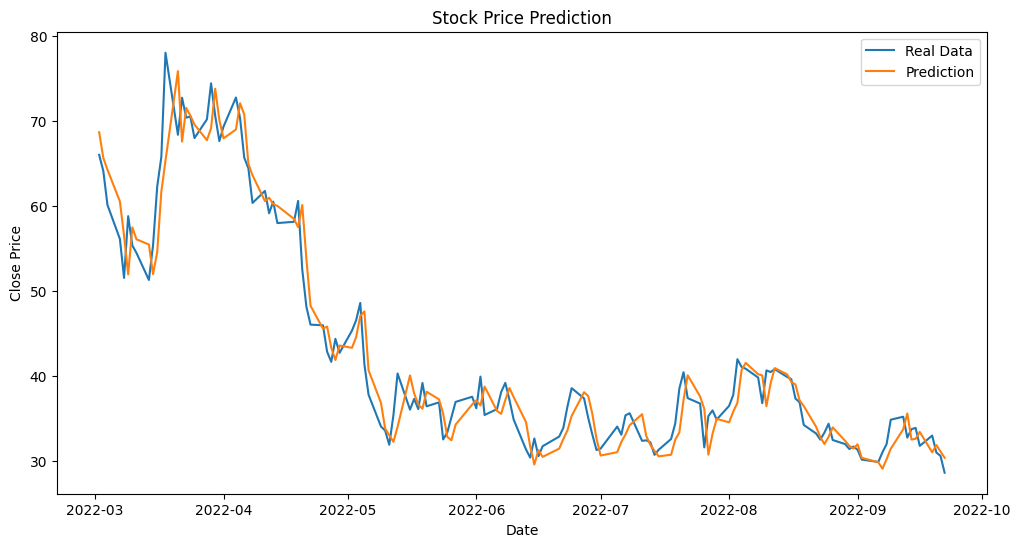

In [236]:
ts_pred_new = ts_model_new.predict(valid_dataset_new)

plt.figure(figsize=(12,6))
# Plot the actual stock prices (from the split time onwards)
plt.plot(stock_data.index[split_time + WINDOW_SIZE:], stock_data['Close'][split_time + WINDOW_SIZE:], label = 'Real Data')

plt.plot(stock_data.index[split_time + WINDOW_SIZE:], price_scaler.inverse_transform(ts_pred_new), label = 'Prediction')

plt.title('Stock Price Prediction')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()

In [237]:
print("R2 Score for the model:", r2_score(stock_data['Close'][split_time + WINDOW_SIZE:], price_scaler.inverse_transform(ts_pred_new)))

R2 Score for the model: 0.9477878732487699
